<a href="https://colab.research.google.com/github/RGarancs/applied-ai-academy-labs/blob/main/solutions/aiact.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EU AI Act classification exercise (20 systems)

**Applied AI Academy — problem set with worked answers**

**Used in:** Lesson 18 — The EU AI Act is a risk ladder — classify first, then comply by design  
**Rows:** 20  ·  **Source file:** `eu_ai_act_classification.csv`



---
### How to use this notebook
Run the cells in order. Each problem is stated first, then solved, then the
answer is spelled out. For teaching, hide the solution cells and let the room
attempt the task before revealing them.

> The data loads straight from `appliedai.center` — nothing to upload.


## Setup

In [1]:
%matplotlib inline
import pandas as pd, numpy as np, os, urllib.request
import matplotlib, matplotlib.pyplot as plt
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

# Applied AI Academy chart style — calm, legible when projected
INK, ACCENT, CORE, BUILDER, DANGER = "#26214a", "#544d94", "#5b8a6e", "#a8845c", "#b05a5a"
matplotlib.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c4d8", "axes.labelcolor": INK, "axes.titlesize": 13,
    "axes.titleweight": "600", "axes.titlecolor": INK, "axes.titlepad": 14,
    "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 10, "grid.color": "#e6e2ef", "axes.grid": True,
    "axes.axisbelow": True, "grid.linewidth": .8, "figure.facecolor": "white",
})

URL   = "https://appliedai.center/assets/datasets/eu_ai_act_classification.csv"
LOCAL = "eu_ai_act_classification.csv"
if not os.path.exists(LOCAL):
    print("Downloading", URL)
    urllib.request.urlretrieve(URL, LOCAL)

df = pd.read_csv(LOCAL, low_memory=False)
print("Shape:", df.shape)
df.head()

Shape: (20, 4)


,system,description,correct_tier,rationale
0,Spam filter for corporate email,Filters unwanted email using ML,minimal,No Annex III category; negligible rights impact.
1,CV screening & ranking for hiring,Scores and ranks job applicants,high-risk,"Employment (Annex III): bias testing, transpar..."
2,Customer service chatbot,Answers product questions on a website,limited,Transparency duty: users must know they talk t...
3,Consumer credit scoring,Scores natural persons for loan approval,high-risk,"Essential services (Annex III): documentation,..."
4,Marketing video generator,Creates promotional videos with synthetic pres...,limited,Synthetic content must be labelled; deepfake-t...


## What is in the file

In [2]:
print("Columns and types:")
print(df.dtypes.to_string())
miss = df.isna().sum()
miss = miss[miss > 0]
print("\nMissing values:" if len(miss) else "\nNo missing values.")
if len(miss): print(miss.to_string())

Columns and types:
system          str
description     str
correct_tier    str
rationale       str

No missing values.


---
## Problem 1 · Easy — describe

Read the twenty systems and classify them yourself before looking.

*Try it yourself first. The worked solution is below.*

In [3]:
print(df[["system","description"]].to_string(index=False, max_colwidth=78))

                                    system                                          description
           Spam filter for corporate email                      Filters unwanted email using ML
         CV screening & ranking for hiring                      Scores and ranks job applicants
                  Customer service chatbot               Answers product questions on a website
                   Consumer credit scoring             Scores natural persons for loan approval
                 Marketing video generator Creates promotional videos with synthetic presenters
    Emotion recognition in exam proctoring                Detects student emotions during exams
          Predictive maintenance for pumps                Predicts industrial equipment failure
Social scoring by loyalty 'citizen points'              Gates services based on behaviour score
                    Exam grading assistant               Scores student essays for final grades
              Warehouse robot path plann

---
## Problem 2 · Intermediate — build

Check yourself against the official tiers.

*Try it yourself first. The worked solution is below.*

In [4]:
print(df["correct_tier"].value_counts(), "\n")
print(df[["system","correct_tier"]].to_string(index=False))

correct_tier
minimal       6
high-risk     6
prohibited    5
limited       3
Name: count, dtype: int64 

                                    system correct_tier
           Spam filter for corporate email      minimal
         CV screening & ranking for hiring    high-risk
                  Customer service chatbot      limited
                   Consumer credit scoring    high-risk
                 Marketing video generator      limited
    Emotion recognition in exam proctoring   prohibited
          Predictive maintenance for pumps      minimal
Social scoring by loyalty 'citizen points'   prohibited
                    Exam grading assistant    high-risk
              Warehouse robot path planner      minimal
                     Emergency call triage    high-risk
                     AI meme generator app      limited
 Biometric ID in public square (real-time)   prohibited
Insurance premium pricing for health cover    high-risk
          Code autocomplete for developers      minimal

---
## Problem 3 · Advanced — judge

Read the rationales — the reasoning is the transferable part.

*Try it yourself first. The worked solution is below.*

In [5]:
for _, r in df.iterrows():
    print(f"\n{r['system']}\n  TIER: {r['correct_tier']}\n  WHY : {r['rationale']}")


Spam filter for corporate email
  TIER: minimal
  WHY : No Annex III category; negligible rights impact.

CV screening & ranking for hiring
  TIER: high-risk
  WHY : Employment (Annex III): bias testing, transparency, human oversight required.

Customer service chatbot
  TIER: limited
  WHY : Transparency duty: users must know they talk to AI (Art. 50).

Consumer credit scoring
  TIER: high-risk
  WHY : Essential services (Annex III): documentation, oversight, robustness.

Marketing video generator
  TIER: limited
  WHY : Synthetic content must be labelled; deepfake-type disclosure.

Emotion recognition in exam proctoring
  TIER: prohibited
  WHY : Emotion recognition in education is banned (Art. 5).

Predictive maintenance for pumps
  TIER: minimal
  WHY : No rights impact; unless safety component under sector law.

Social scoring by loyalty 'citizen points'
  TIER: prohibited
  WHY : Social scoring is a banned practice (Art. 5).

Exam grading assistant
  TIER: high-risk
  WHY : Educ

---
## Visual summary

The same answers, as pictures. These are what to project — a room reads a chart
far faster than it reads a table, and the shape of a result is usually the
argument you are actually making.

findfont: Failed to find font weight 600, now using 700.


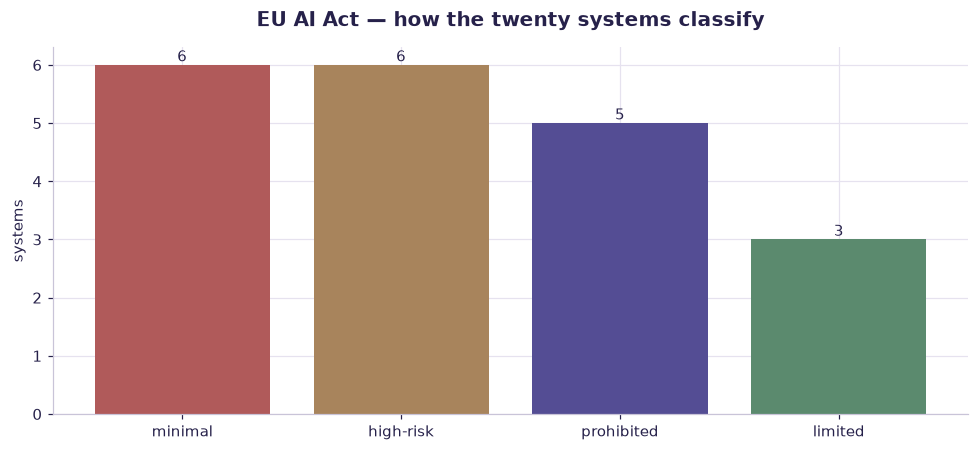

In [6]:
r = df["correct_tier"].value_counts()
fig, ax = plt.subplots(figsize=(9, 4.2))
b = ax.bar(r.index.astype(str), r.values, color=[DANGER, BUILDER, ACCENT, CORE][:len(r)])
ax.bar_label(b, fontsize=10)
ax.set_title("EU AI Act — how the twenty systems classify"); ax.set_ylabel("systems")
plt.tight_layout(); plt.show()

---
## Verified answer key

These are the numbers the academy ships for this dataset. They were computed
from this exact file — if your run disagrees, reconcile before teaching it.

1. Tier mix: 6 minimal · 6 high-risk · 3 limited/transparency · 5 prohibited
2. The 5 prohibited: exam-proctoring emotion detection, workplace emotion tracking, social scoring, real-time public biometric ID, manipulative dark-pattern agents
3. The classic confusions: chatbots are LIMITED not minimal (disclosure duty); grading assistants are HIGH-RISK (education access); internal RAG is minimal (but GDPR still applies)


---
## Teaching notes

* **Run the Easy problem live.** It sets the shared vocabulary and gets everyone
  looking at the same rows.
* **Let them fail on the Intermediate one.** The productive mistake is usually
  reaching for a model before checking the data.
* **Argue about the Advanced one.** It has no single right answer; it has a
  defensible one, and defending it is the skill being taught.
* **Always close on limitations.** Every dataset here has a real caveat —
  scrape bias, a tiny sample, a hindsight label. Naming it is the lesson.
* **Deliverable for learners:** Risk-tier classification of the 8 systems + one completed compliance canvas.

---
*Applied AI Academy · appliedai.center*
